## Laplacegleichung auf Rechteck
Das Notebook illustriert die numerische Lösung der Laplacegleichung 

$$
    u_{.xx} + u_{.yy} = 0
$$

auf einem Rechteck

$$
    \Omega = [a, b] \times [c, d]
$$

mit Randbedingungen auf den Rändern $x = a$, $x = b$, $y = c$, $y = d$

### Gitterpunkte erzeugen
Im ersten Schritt werden die Koordinaten aller Gitterpunkte erzeugt und in ein Array geschrieben. Dieses Array enthält dann 

$$
    N = (n+1) \cdot (m+1)
$$

Punkte (und natürlich für jeden Punkt zwei Koordinaten).

(861, 2)


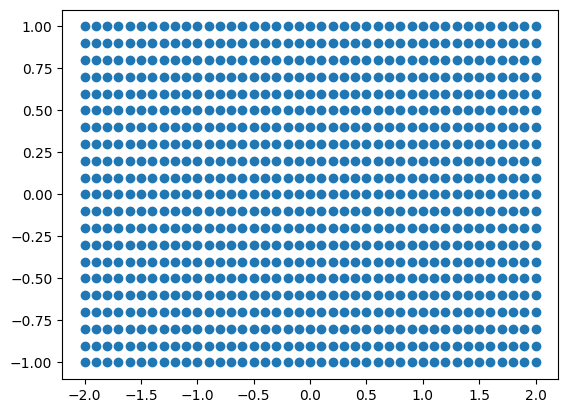

In [2]:
import numpy as np
import matplotlib.pyplot as plt

a, b, c, d = -2, 2, -1, 1   # Grenzen, wie oben definiert
B, H = b - a, d - c         # Abmessungen (Breite, Höhe) des Rechtecks
h    = 0.1                  # Seitenlänge eines Quadrats der Unterteilung

m, n = int(H / h), int(B / h)      # Anzahl Punkte in x bzw. y Richtung B/h und H/h sollten ganzzahlig sein!

xi = a + np.linspace(0, B, n+1)    # Zwischen- und Randpunkte der Unterteilung in x-Richtung
yi = c + np.linspace(0, H, m+1)    # Zwischen- und Randpunkte der Unterteilung in y-Richtung

Xi, Yi = np.meshgrid(xi, yi)       # meshgrid erzeugt ein Raster (aka Gitterpunkte) aus gegebenen x und y Koordinaten
pnts = np.array([Xi.flatten(),Yi.flatten()]).T # pnts ist das N x 2 Array mit allen Punkten des Gitters

plt.figure()
plt.scatter(pnts[:,0], pnts[:,1])

print(pnts.shape)


### Randpunkte und innere Punkte definieren

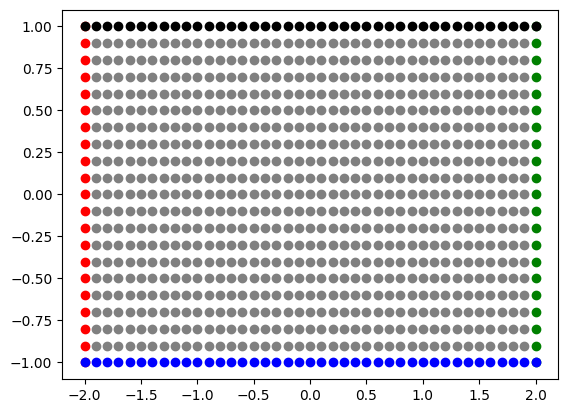

In [3]:
# %% Randpunkte links, rechts, unten, oben (logische Arrays)

bndXa = (pnts[:,0]<xi[0]+h/2)   # x = a 
bndXb = (xi[-1]-h/2<pnts[:,0])  # x = b
bndYc = (pnts[:,1]<yi[0]+h/2)   # y = c
bndYd = (yi[-1]-h/2<pnts[:,1])  # y = d

bnd = bndXa + bndXb + bndYc + bndYd    # "+" für logische Arrays bedeutet "oder"

plt.figure()
plt.scatter(pnts[~bnd,0], pnts[~bnd,1], color = "gray")     # innere Punkte ~bnd = alle Punkte, wo bnd == False ist
plt.scatter(pnts[bndXa,0], pnts[bndXa,1], color = "red")
plt.scatter(pnts[bndXb,0], pnts[bndXb,1], color = "green")
plt.scatter(pnts[bndYc,0], pnts[bndYc,1], color = "blue")
plt.scatter(pnts[bndYd,0], pnts[bndYd,1], color = "black")

Werte für die Randpunkte sind vorgegeben. Die diskretisierte Gleichung für einen Inneren Punkt lautet

$$
	4 u_k - u_{k+1} - u_{k-1} - u_{k+n+1} - u_{k-n-1} = 0
$$

Die Punkte, wo Randbedingungen gelten müssen jeweils auf die rechte Seite der Gleichung. Dies kann man wie folgt ausdrücken:

$$
    A \cdot (\vec{u} + \vec{u}_0) = 0
$$

dabei ist $A \in \mathbb{R}^{N \times N}$ und $\vec{u} \in \mathbb{R}^{N}$. Der Vektor $\vec{u}_0 \in \mathbb{R}^{N}$ enthält dann die Randbedingungen, d.h. 

$$
        u_{0, k}
$$

enthält die Randbedingung für den Punkt $k$, falls es zu diesem Punkt eine Randbedingung gibt und ist andernfalls gleich Null. 


In [4]:
# %% linearer Index für alle Punkte
ndofs = pnts.shape[0]       # Anzahl Punkte (inklusive Randpunkte)
dofs = np.arange(0,ndofs)   # linearer Index für alle Punkte, entspricht etwa dem Index k in der obigen Gleichung
freedofs = dofs[(~bnd)]     # Indices der inneren Punkte
                
# Randbedingungen --> entsprechen der Lösung x**2 - y**2 der Laplacegleichung
u0 = np.zeros_like(dofs,dtype=float)
u0[bndXa] = a**2 - yi**2
u0[bndXb] = b**2 - yi**2
u0[bndYc] = xi**2 - c**2
u0[bndYd] = xi**2 - d**2  

print("Anzahl Punkte im Raster: ", ndofs)
print("Anzahl innere Punkte:    ", np.sum(~bnd))


Anzahl Punkte im Raster:  861
Anzahl innere Punkte:     741


Das LGS lautet damit

$$
    A \cdot \vec{u} = - A \cdot \vec{u}_0
$$

mit bekannter rechter Seite. Als nächstes wird die Matrix $A$ aufgebaut. Der *stencil* codiert dabei die Differenzenquotienten und das Indexarray *indstencil* enthält die (relativen) Indices. $A$ ist eine Matrix mit Bandstruktur.

Da das LGS nur für die Punkte _ohne_ Randbedingung gelöst werden muss, kann die Matrix $A$ "reduziert" werden, indem alle Zeilen und Spalten, die sich auf Punkte mit Randbedingung beziehen aus $A$ entfernt werden. 

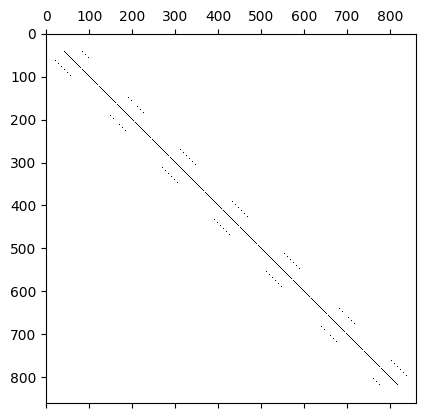

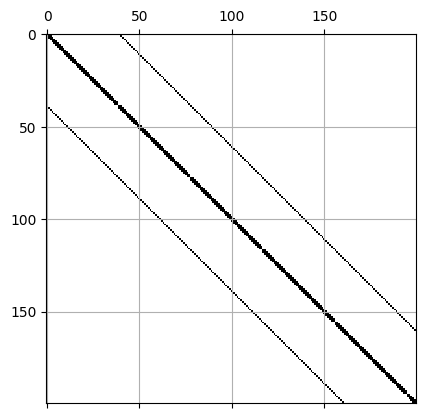

In [5]:
# stencil -> praktischer shortcut für die Gewichte und Indices in den Differenzenquotienten
stencil = np.array([4,-1,-1,-1,-1])    # s. Differenzenquotienten
indstencil = np.array([0,-1,1,-(n+1),n+1]) # relativer Index fuer den Differenzen-Quotient

# Matrix des LGS aufbauen
A=np.zeros((ndofs,ndofs))
for i in range(len(freedofs)): 
    A[freedofs[i],freedofs[i]+indstencil] = stencil # Stencil wird nur bei den inneren Freiheitsgrade dazu addiert

Ared = A[np.ix_(freedofs,freedofs)]   # Reduzierte Matrix A: nur die Einträge (Zeilen / Spalten), für die das LGS tatsächlich gelöst werden muss
bRed = - (A @ u0)[freedofs]

plt.figure()
plt.spy(A)

plt.figure()
plt.spy(Ared[:200, :200], aspect = "equal")
plt.grid()

Die Matrix $A_{\textrm{red}}$ ist symmetrisch und positiv definit. Um das LGS zu lösen, verwenden wir die Cholesky-Zerlegung.

(21, 41)


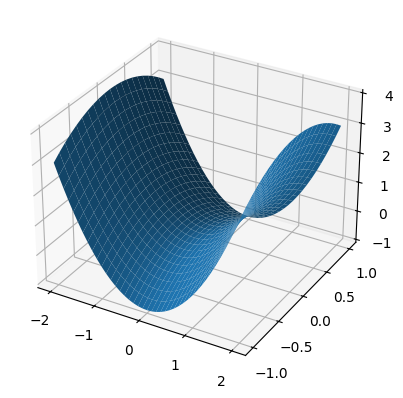

In [20]:
def fbSubs(L, b):
    n = L.shape[0]
 
    y = np.zeros_like(b)
    y[0] = b[0] / L[0,0]
    for i in range(1, n):
        y[i] = (b[i] - L[i, :i] @ y[:i]) / L[i,i]
    assert( np.linalg.norm(L @ y - b) < 1e-10)
    
    x = np.zeros_like(y)
    x[-1] = y[-1] / L[-1,-1]
    for i in range(n-2, -1, -1):
        x[i] = (y[i] - L[i+1:, i] @ x[i+1:]) / L[i,i]
    assert( np.linalg.norm(L.T @ x - y) < 1e-10)
    
    return x
    
L = np.linalg.cholesky(Ared)

uRed = fbSubs(L, bRed)

u = u0.copy() # initialisieren mit phi0
u[freedofs] += uRed
u = np.reshape(u, Xi.shape) # auf 2d-Form zurückbringen

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(Xi, Yi, u)

print(u.shape)


Wir berechnen noch das (negative) Gradientenvektorfeld 

$$
    \vec{v} = - \nabla u
$$

unserer Lösung mit Hilfe von zentralen Differenzenquotienten:

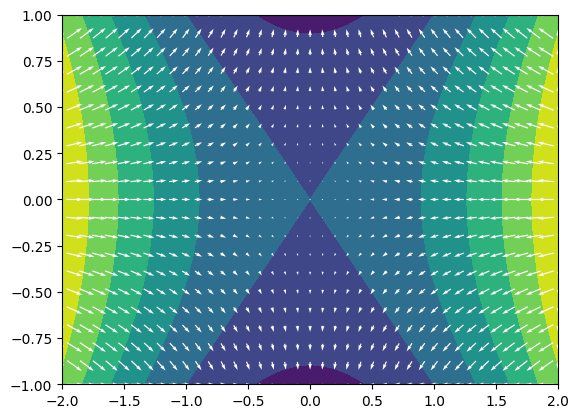

In [33]:
vx = np.zeros_like(u)
vy = np.zeros_like(u)

vx[:,1:-1] = - (u[:,2:] - u[:,:-2])/(2*h)
vy[1:-1,:] = - (u[2:,:] - u[:-2,:])/(2*h)

plt.contourf(Xi, Yi, u)
# quiver zeichnet ein Vektorfeld. Die Option angles = "xy" passt die Pfeilrichtung an die Skalierung der Achsen an.
plt.quiver(Xi, Yi, vx, vy, angles = "xy", color = "white", pivot = "middle") 

Schliesslich zum Vergleich die "theoretische Lösung" $x^2 - y^2$

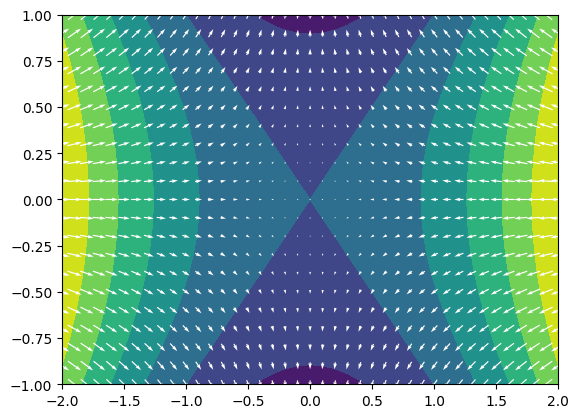

In [34]:
plt.contourf(Xi, Yi, Xi**2 - Yi**2)
plt.quiver(Xi, Yi, - 2 * Xi, 2 * Yi, angles = "xy", color = "white", pivot = "middle")